# Customer-Level Uplift Modeling

## Introduction

The previous notebooks answered two important questions:

1. Did the email campaigns improve outcomes?
2. Were the observed effects statistically reliable?

This notebook asks a more advanced business question:

> Which customers are most likely to benefit from receiving an email?

This is different from ordinary predictive modeling.

A normal conversion model predicts:

> Who is likely to purchase?

An uplift model predicts:

> Whose purchase probability changes because of treatment?

That distinction matters.

A customer who would purchase anyway may not need an email.

A customer who will never purchase may also not be worth targeting.

The most valuable customers are often those whose behavior changes because of the campaign.

## Workflow

Customer features  
→ Treatment assignment  
→ Separate treatment and control models  
→ Predict potential outcomes  
→ Estimate customer-level uplift  
→ Rank customers  
→ Evaluate targeting strategy  
→ Estimate business value

In [1]:
# Core data tools
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    log_loss
)

In [2]:
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:,.4f}".format)

In [4]:
# Load cleaned data
DATA_PATH = "../data/processed/hillstrom_cleaned.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.4400,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0000
1,6,3) $200 - $350,329.0800,1,1,Rural,1,Web,No E-Mail,0,0,0.0000
2,7,2) $100 - $200,180.6500,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0000
3,9,5) $500 - $750,675.8300,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0000
4,2,1) $0 - $100,45.3400,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0000


Validate the data

In [5]:
# Check dataset structure
print("Dataset shape:", df.shape)
print("\nMissing values:", df.isna().sum().sum())
print("\nExperiment groups:")
print(df["segment"].value_counts())

Dataset shape: (64000, 12)

Missing values: 0

Experiment groups:
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64


## Feature Selection and Leakage Prevention

Uplift modeling requires special care with feature selection.

We may only use information that was available **before treatment assignment**.

Therefore, we must exclude:

- `segment` — this defines treatment assignment
- `visit` — this occurs after treatment
- `conversion` — this is the outcome
- `spend` — this occurs after treatment

Using post-treatment variables would create leakage and invalidate the customer targeting model.

The model will use only pre-treatment customer characteristics.

In [6]:
# Features available before treatment
feature_columns = [
    "recency",
    "history_segment",
    "history",
    "mens",
    "womens",
    "zip_code",
    "newbie",
    "channel"
]

# Binary outcome
target_column = "conversion"

feature_columns

['recency',
 'history_segment',
 'history',
 'mens',
 'womens',
 'zip_code',
 'newbie',
 'channel']

Mens E-Mail
vs
No E-Mail

# Part 1: Mens E-Mail Uplift Model

We first estimate heterogeneous treatment effects for:

- Treatment: Mens E-Mail
- Control: No E-Mail

The Womens E-Mail group is temporarily excluded from this comparison.

This gives us a clean binary treatment problem.

In [7]:
# Keep only Mens E-Mail and No E-Mail groups
mens_df = df[
    df["segment"].isin([
        "Mens E-Mail",
        "No E-Mail"
    ])
].copy()

# Create binary treatment indicator
mens_df["treatment"] = (
    mens_df["segment"] == "Mens E-Mail"
).astype(int)

# Check treatment distribution
mens_df["treatment"].value_counts()

treatment
1    21307
0    21306
Name: count, dtype: int64

Build modeling dataset

In [8]:
# Customer features
X = mens_df[feature_columns].copy()

# Conversion outcome
y = mens_df[target_column].copy()

# Treatment assignment
treatment = mens_df["treatment"].copy()

print("X shape:", X.shape)
print("Outcome rate:", y.mean())
print("Treatment rate:", treatment.mean())

X shape: (42613, 8)
Outcome rate: 0.009128669654800178
Treatment rate: 0.5000117335085538


In [12]:
X

,recency,history_segment,history,mens,womens,zip_code,newbie,channel
1,6,3) $200 - $350,329.0800,1,1,Rural,1,Web
3,9,5) $500 - $750,675.8300,1,0,Rural,1,Web
8,9,5) $500 - $750,675.0700,1,1,Rural,1,Phone
13,2,2) $100 - $200,101.6400,0,1,Urban,0,Web
14,4,3) $200 - $350,241.4200,0,1,Rural,1,Multichannel
...,...,...,...,...,...,...,...,...
63994,7,1) $0 - $100,86.4600,0,1,Urban,0,Web
63995,10,2) $100 - $200,105.5400,1,0,Urban,0,Web
63996,5,1) $0 - $100,38.9100,0,1,Urban,1,Phone
63997,6,1) $0 - $100,29.9900,1,0,Urban,1,Phone


In [13]:
y

1        0
3        0
8        0
13       0
14       0
        ..
63994    0
63995    0
63996    0
63997    0
63999    0
Name: conversion, Length: 42613, dtype: int64

In [14]:
treatment

1        0
3        1
8        1
13       1
14       0
        ..
63994    1
63995    1
63996    1
63997    1
63999    1
Name: treatment, Length: 42613, dtype: int64

Split correctly

In [9]:
# Combine treatment and outcome for stratification
stratify_key = (
    treatment.astype(str)
    + "_"
    + y.astype(str)
)

In [10]:
# Split customer indices
train_idx, test_idx = train_test_split(
    np.arange(len(X)),
    test_size=0.25,
    random_state=42,
    stratify=stratify_key
)


In [11]:
train_idx

array([21103, 21758,   364, ...,  5398, 26956, 35891], shape=(31959,))

In [15]:
# Create train data
X_train = X.iloc[train_idx].copy()
y_train = y.iloc[train_idx].copy()
treatment_train = treatment.iloc[train_idx].copy()

In [16]:
# Create test data
X_test = X.iloc[test_idx].copy()
y_test = y.iloc[test_idx].copy()
treatment_test = treatment.iloc[test_idx].copy()

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 31959
Test size: 10654


Define feature Types

In [17]:
# Numerical features
numerical_features = [
    "recency",
    "history"
]

# Categorical features
categorical_features = [
    "history_segment",
    "mens",
    "womens",
    "zip_code",
    "newbie",
    "channel"
]

Build Preprocessing

In [18]:
# Numerical preprocessing
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Categorical preprocessing
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

## T-Learner Strategy

We use a T-Learner.

The idea is simple:

### Treatment model

Train a model using customers who received Mens E-Mail:

> P(conversion | customer features, treated)

### Control model

Train a separate model using customers who received No E-Mail:

> P(conversion | customer features, untreated)

For each customer:

> Predicted uplift = Predicted treatment probability - Predicted control probability

This gives an estimated customer-level treatment effect.

In [19]:
# Identify treated and control customers
treated_mask = treatment_train == 1
control_mask = treatment_train == 0

# Treatment training data
X_train_treated = X_train.loc[treated_mask]
y_train_treated = y_train.loc[treated_mask]

In [20]:
# Control training data
X_train_control = X_train.loc[control_mask]
y_train_control = y_train.loc[control_mask]

print("Treatment training rows:", len(X_train_treated))
print("Control training rows:", len(X_train_control))

Treatment training rows: 15980
Control training rows: 15979


#### Create treatment model

In [21]:
# Treatment model:
# Predict conversion probability if customer receives Mens E-Mail
treatment_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

#### Create control model

In [22]:
# Control model:
# Predict conversion probability if customer receives no email
control_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

#### Train treatment model

In [23]:
# Train treatment model
treatment_model.fit(
    X_train_treated,
    y_train_treated
)

print("Treatment model trained.")

Treatment model trained.


In [24]:
# Train control model
control_model.fit(
    X_train_control,
    y_train_control
)

print("Control model trained.")

Control model trained.


## Predicting Potential Outcomes

For every customer in the test set, we generate two predictions:

1. Estimated conversion probability if treated
2. Estimated conversion probability if untreated

We can never observe both outcomes for the same real customer.

This is the fundamental causal inference problem.

The model estimates the missing counterfactual outcome.

In [25]:
# Predicted conversion probability under treatment
p_treatment = treatment_model.predict_proba(
    X_test
)[:, 1]

# Predicted conversion probability under control
p_control = control_model.predict_proba(
    X_test
)[:, 1]

print("Treatment predictions:", p_treatment[:5])
print("Control predictions:", p_control[:5])

Treatment predictions: [0.40289066 0.70142771 0.29149874 0.6423771  0.62391538]
Control predictions: [0.32630968 0.66186844 0.14718775 0.75189105 0.80867269]


Calculate predicted uplift

In [26]:
# Estimate customer-level uplift
predicted_uplift = (
    p_treatment
    - p_control
)

predicted_uplift[:10]

array([ 0.07658098,  0.03955927,  0.14431098, -0.10951396, -0.1847573 ,
        0.28586726,  0.09272454, -0.04274612,  0.05603245,  0.0966712 ])

In [27]:
# Create customer-level uplift results
uplift_results = X_test.copy()

uplift_results["actual_conversion"] = y_test.values
uplift_results["actual_treatment"] = treatment_test.values

uplift_results["p_conversion_treated"] = p_treatment
uplift_results["p_conversion_control"] = p_control

uplift_results["predicted_uplift"] = predicted_uplift

uplift_results.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,actual_conversion,actual_treatment,p_conversion_treated,p_conversion_control,predicted_uplift
39518,2,1) $0 - $100,33.4600,1,0,Surburban,1,Phone,0,1,0.4029,0.3263,0.0766
46286,8,4) $350 - $500,373.1700,1,1,Surburban,0,Web,0,0,0.7014,0.6619,0.0396
44136,9,2) $100 - $200,124.8100,0,1,Urban,1,Phone,0,1,0.2915,0.1472,0.1443
58561,2,4) $350 - $500,381.1600,1,0,Surburban,0,Multichannel,0,1,0.6424,0.7519,-0.1095
50736,1,4) $350 - $500,393.6900,1,0,Urban,0,Multichannel,0,0,0.6239,0.8087,-0.1848


Summarize uplift distribution

In [28]:
# Summary statistics for predicted uplift
uplift_results["predicted_uplift"].describe()

count   10,654.0000
mean         0.0480
std          0.1253
min         -0.2671
25%         -0.0414
50%          0.0569
75%          0.1421
max          0.4887
Name: predicted_uplift, dtype: float64

Visualize uplift distribution

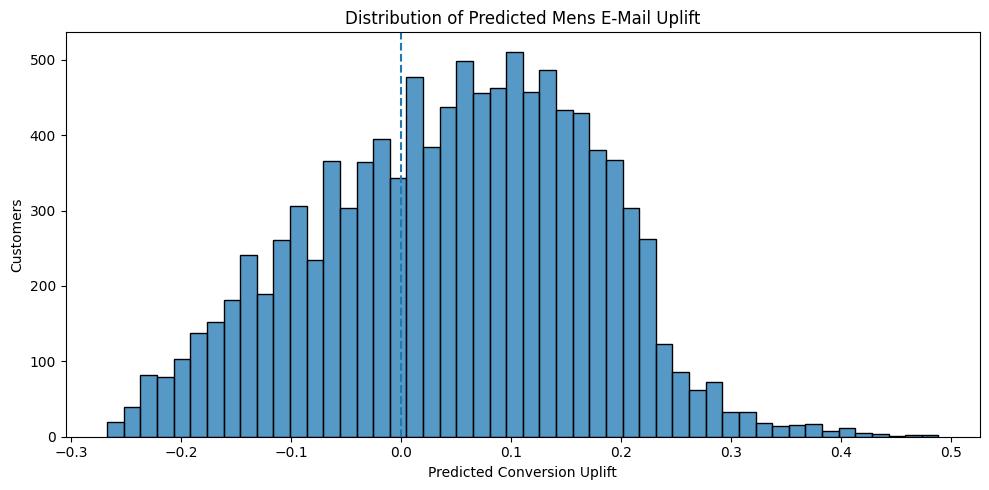

In [29]:
# Visualize predicted customer-level uplift
plt.figure(figsize=(10, 5))

sns.histplot(
    data=uplift_results,
    x="predicted_uplift",
    bins=50
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution of Predicted Mens E-Mail Uplift")
plt.xlabel("Predicted Conversion Uplift")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

### Chart Interpretation

The distribution shows that predicted treatment effects differ across customers.

Some customers have:

- positive predicted uplift
- near-zero predicted uplift
- potentially negative predicted uplift

This is the key insight behind uplift modeling.

The average A/B test tells us whether a campaign works overall.

The uplift model attempts to identify which specific customers are most likely to change behavior because of the campaign.

### Business Implication

Customers with the highest positive predicted uplift should be prioritized for targeting.

Customers with near-zero uplift may not need the campaign.

Customers with negative predicted uplift may potentially respond worse after treatment and should be treated cautiously.

The targeting strategy becomes:

> Rank customers by predicted uplift → contact highest-value customers first

In [30]:
# Rank customers from highest to lowest predicted uplift
uplift_results = uplift_results.sort_values(
    "predicted_uplift",
    ascending=False
).copy()

# Divide customers into 10 equally sized groups
uplift_results["uplift_decile"] = pd.qcut(
    uplift_results["predicted_uplift"].rank(
        method="first",
        ascending=False
    ),
    q=10,
    labels=False
) + 1

uplift_results.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,actual_conversion,actual_treatment,p_conversion_treated,p_conversion_control,predicted_uplift,uplift_decile
10617,10,"6) $750 - $1,000",770.9000,1,1,Surburban,1,Multichannel,0,1,0.7048,0.2160,0.4887,1
48093,11,"6) $750 - $1,000",811.0400,1,1,Surburban,1,Web,0,1,0.6846,0.2092,0.4754,1
27530,9,"6) $750 - $1,000",768.0600,1,1,Surburban,1,Multichannel,0,1,0.7117,0.2401,0.4716,1
33410,9,"6) $750 - $1,000",910.0700,1,1,Surburban,1,Multichannel,0,1,0.7170,0.2528,0.4642,1
53567,11,"6) $750 - $1,000",759.7000,1,1,Urban,1,Multichannel,0,0,0.6721,0.2236,0.4485,1


Evaluate observed treatment effect by decile

In [32]:
# Calculate observed treatment effect within each uplift decile
decile_summary = (
    uplift_results
    .groupby("uplift_decile")
    .apply(
        lambda group: pd.Series({
            "customers": len(group),

            "treated_conversion_rate": (
                group.loc[
                    group["actual_treatment"] == 1,
                    "actual_conversion"
                ].mean()
            ),

            "control_conversion_rate": (
                group.loc[
                    group["actual_treatment"] == 0,
                    "actual_conversion"
                ].mean()
            ),

            "observed_uplift": (
                group.loc[
                    group["actual_treatment"] == 1,
                    "actual_conversion"
                ].mean()
                -
                group.loc[
                    group["actual_treatment"] == 0,
                    "actual_conversion"
                ].mean()
            ),

            "avg_predicted_uplift": (
                group["predicted_uplift"].mean()
            )
        })
    )
    .reset_index()
)

decile_summary

C:\Users\tevin\AppData\Local\Temp\ipykernel_14624\1352807224.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,uplift_decile,customers,treated_conversion_rate,control_conversion_rate,observed_uplift,avg_predicted_uplift
0,1,"1,066.0000",0.0125,0.0039,0.0086,0.2494
1,2,"1,065.0000",0.0118,0.0036,0.0082,0.1799
2,3,"1,065.0000",0.0148,0.0038,0.0110,0.1421
3,4,"1,066.0000",0.0130,0.0038,0.0093,0.1084
4,5,"1,065.0000",0.0133,0.0130,0.0003,0.0743
5,6,"1,065.0000",0.0058,0.0036,0.0022,0.0394
6,7,"1,066.0000",0.0113,0.0075,0.0039,0.0006
7,8,"1,065.0000",0.0094,0.0075,0.0018,-0.0429
8,9,"1,065.0000",0.0130,0.0038,0.0092,-0.0955
9,10,"1,066.0000",0.0204,0.0076,0.0129,-0.1754


Visualize observed uplift by decile

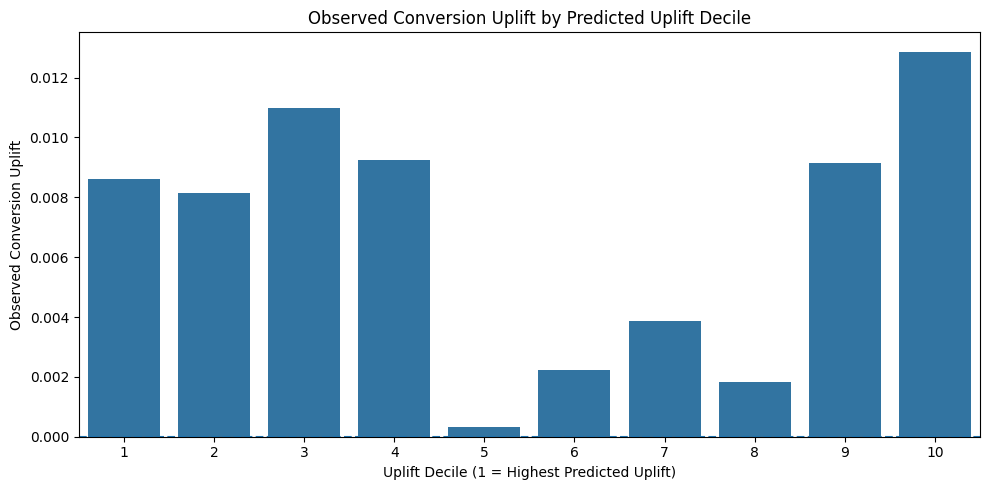

In [33]:
# Visualize observed treatment effect by predicted uplift decile
plt.figure(figsize=(10, 5))

sns.barplot(
    data=decile_summary,
    x="uplift_decile",
    y="observed_uplift",
    errorbar=None
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Observed Conversion Uplift by Predicted Uplift Decile")
plt.xlabel("Uplift Decile (1 = Highest Predicted Uplift)")
plt.ylabel("Observed Conversion Uplift")
plt.tight_layout()
plt.show()

### Decile Analysis Interpretation

This chart evaluates whether customers ranked as high uplift actually demonstrate stronger observed treatment effects.

The ideal pattern is:

- Decile 1 shows strong positive uplift
- Higher-ranked deciles outperform lower-ranked deciles
- Low-ranked customers show weak, zero, or negative uplift

If this pattern appears, the model is successfully separating customers based on treatment responsiveness.

### Business Implication

A strong ranking pattern means the company does not need to email every customer.

Instead, it can prioritize the highest-uplift customer groups.

This can potentially:

- reduce campaign volume
- reduce marketing cost
- improve conversion efficiency
- protect customers from unnecessary messaging
- increase incremental ROI

In [34]:
# Mark top 20% of customers by predicted uplift
uplift_results["target_top_20_pct"] = (
    uplift_results["uplift_decile"] <= 2
)

# Check targeting counts
uplift_results["target_top_20_pct"].value_counts()

target_top_20_pct
False    8523
True     2131
Name: count, dtype: int64

Compare top 20% vs all customers

In [35]:
# Top 20% customers
top_20 = uplift_results[
    uplift_results["target_top_20_pct"]
].copy()

# Observed treatment effect among top 20%
top_20_treated_rate = (
    top_20.loc[
        top_20["actual_treatment"] == 1,
        "actual_conversion"
    ].mean()
)

top_20_control_rate = (
    top_20.loc[
        top_20["actual_treatment"] == 0,
        "actual_conversion"
    ].mean()
)

top_20_observed_uplift = (
    top_20_treated_rate
    - top_20_control_rate
)

print(f"Top 20% treated conversion rate: {top_20_treated_rate:.4%}")
print(f"Top 20% control conversion rate: {top_20_control_rate:.4%}")
print(f"Top 20% observed uplift: {top_20_observed_uplift:.4%}")

Top 20% treated conversion rate: 1.2172%
Top 20% control conversion rate: 0.3763%
Top 20% observed uplift: 0.8409%


Compare with full population

In [36]:
# Overall observed treatment effect
overall_treated_rate = (
    uplift_results.loc[
        uplift_results["actual_treatment"] == 1,
        "actual_conversion"
    ].mean()
)

overall_control_rate = (
    uplift_results.loc[
        uplift_results["actual_treatment"] == 0,
        "actual_conversion"
    ].mean()
)

overall_observed_uplift = (
    overall_treated_rate
    - overall_control_rate
)

print(f"Overall treated conversion rate: {overall_treated_rate:.4%}")
print(f"Overall control conversion rate: {overall_control_rate:.4%}")
print(f"Overall observed uplift: {overall_observed_uplift:.4%}")

Overall treated conversion rate: 1.2577%
Overall control conversion rate: 0.5819%
Overall observed uplift: 0.6758%


Final comparison table

In [37]:
# Compare broad targeting with top-20% targeting
targeting_comparison = pd.DataFrame({
    "strategy": [
        "All Customers",
        "Top 20% Predicted Uplift"
    ],
    "treated_conversion_rate": [
        overall_treated_rate,
        top_20_treated_rate
    ],
    "control_conversion_rate": [
        overall_control_rate,
        top_20_control_rate
    ],
    "observed_uplift": [
        overall_observed_uplift,
        top_20_observed_uplift
    ]
})

targeting_comparison

,strategy,treated_conversion_rate,control_conversion_rate,observed_uplift
0,All Customers,0.0126,0.0058,0.0068
1,Top 20% Predicted Uplift,0.0122,0.0038,0.0084


# Final Uplift Modeling Conclusion

The first two notebooks established that email marketing creates measurable average treatment effects.

This notebook extended the analysis to customer-level targeting.

## What We Built

We developed a T-Learner that:

1. Models conversion under treatment
2. Models conversion under control
3. Estimates both potential outcomes for each customer
4. Calculates predicted customer-level uplift
5. Ranks customers by expected treatment benefit
6. Evaluates observed uplift across targeting groups

## Business Value

Traditional conversion modeling asks:

> Who is likely to purchase?

Uplift modeling asks:

> Who is more likely to purchase because we send the email?

That distinction is critical.

A high-conversion customer may already intend to buy without treatment.

Targeting that customer may waste marketing resources.

The strongest targeting candidates are customers with high estimated incremental response.

## Recommended Strategy

The company should move from:

Broad email campaigns

to:

Customer-level uplift ranking  
→ prioritize high-uplift customers  
→ suppress low-value contacts  
→ measure incremental conversion  
→ optimize campaign ROI

## Important Limitation

Customer-level uplift predictions are model-based estimates.

Because the true treated and untreated outcomes cannot both be observed for the same customer, model evaluation must focus on treatment-effect ranking and group-level experimental comparisons rather than ordinary prediction accuracy alone.

## Next Step

The next step is to compare multiple uplift approaches:

- Logistic Regression T-Learner
- Random Forest T-Learner
- Gradient Boosting T-Learner

Then evaluate which model creates the strongest customer ranking.